In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             mean_absolute_percentage_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

PROCESSED = r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\data\processed\\'
REPORTS = r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\reports\\'

In [2]:
df = pd.read_csv(PROCESSED + 'sales_features.csv', parse_dates=['date'])

le = LabelEncoder()
df['item_id_enc'] = le.fit_transform(df['item_id'])
df['dept_id_enc'] = le.fit_transform(df['dept_id'])

feature_cols = ['item_id_enc', 'dept_id_enc',
                'year', 'month', 'week', 'dayofweek',
                'quarter', 'is_weekend', 'is_event',
                'snap_CA', 'lag_7', 'lag_14', 'lag_28',
                'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']

split_date = '2015-12-31'
train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

X_train = train[feature_cols]
y_train = train['sales']
X_test = test[feature_cols]
y_test = test['sales']

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [3]:
mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
mape = mean_absolute_percentage_error(y_test, gb_pred) * 100
r2 = r2_score(y_test, gb_pred)

print("=== Gradient Boosting - Full Evaluation ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

=== Gradient Boosting - Full Evaluation ===
MAE:  1.2393
RMSE: 2.3427
MAPE: 164276803474210720.00%
R²:   0.7017


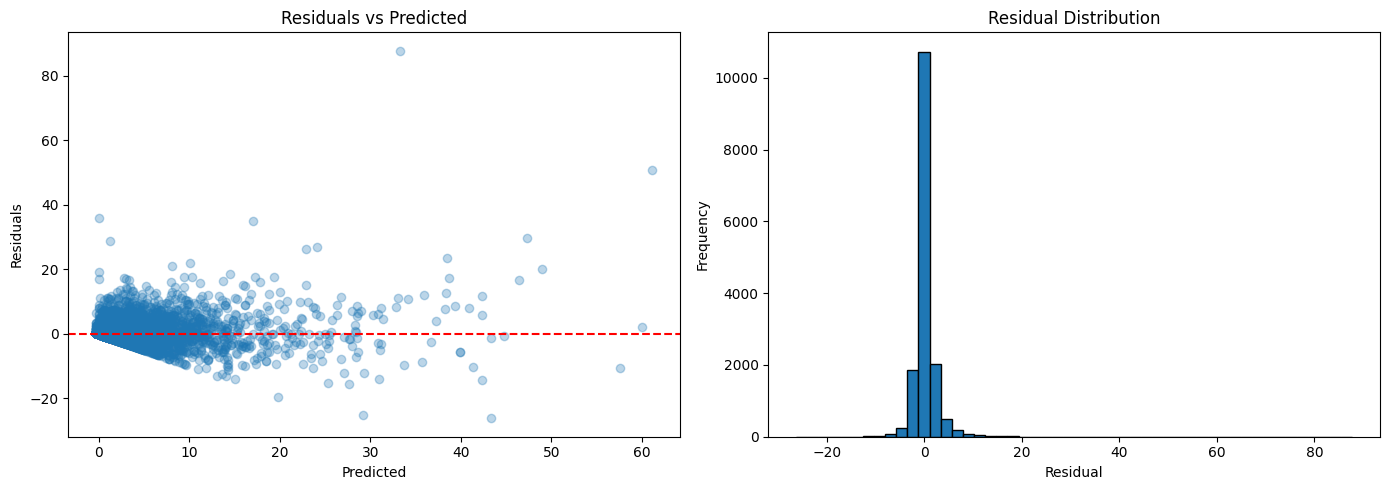

In [4]:
residuals = y_test.values - gb_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(gb_pred, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(REPORTS + 'residual_analysis.png')
plt.show()

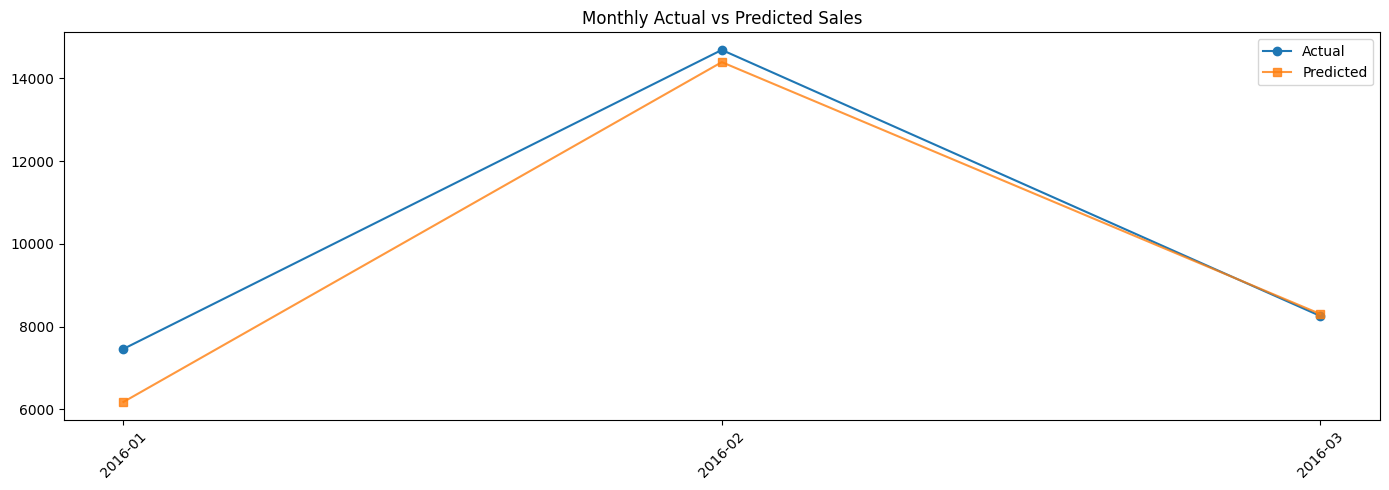

In [5]:
test_results = test.copy()
test_results['predicted'] = gb_pred

monthly = test_results.groupby(test_results['date'].dt.to_period('M')).agg(
    actual=('sales', 'sum'),
    predicted=('predicted', 'sum')
).reset_index()

monthly['date'] = monthly['date'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['date'], monthly['actual'], label='Actual', marker='o')
plt.plot(monthly['date'], monthly['predicted'], label='Predicted', marker='s', alpha=0.8)
plt.xticks(rotation=45)
plt.title('Monthly Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS + 'monthly_forecast.png')
plt.show()

In [6]:
avg_daily_sales = y_test.mean()
avg_error = mae

print("=== Business Interpretation ===")
print(f"Avg daily sales per item: {avg_daily_sales:.2f} units")
print(f"Avg forecast error: {mae:.2f} units")
print(f"Error as % of avg sales: {(mae/avg_daily_sales)*100:.1f}%")
print(f"R² score: {r2:.4f} → model explains {r2*100:.1f}% of sales variance")
print(f"\nInventory insight:")
print(f"  Stock buffer needed: ~{mae*1.5:.1f} units/item/day to cover forecast error")

=== Business Interpretation ===
Avg daily sales per item: 1.92 units
Avg forecast error: 1.24 units
Error as % of avg sales: 64.4%
R² score: 0.7017 → model explains 70.2% of sales variance

Inventory insight:
  Stock buffer needed: ~1.9 units/item/day to cover forecast error
